In [9]:
import sys
sys.path.append('../src')

import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

from numpyro_utils import fit_mcmc
from models import BRCStratified

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
# Read data (pikled)
with open('../data/sim/test_brc_stratified.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
brcs = BRCStratified(data['data'], M=[20, 20], pratio=data['pop_ratio'], type=['plate'])
mcmc = fit_mcmc(0, brcs.model, num_warmup=500, num_samples=500, num_chains=4)

/Users/shozendan/Imperial/0_Research/high_res_brc/notebooks/../src/numpyro_utils.py:24: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 1000/1000 [01:48<00:00,  9.24it/s, 1023 steps of size 1.95e-03. acc. prob=0.94]


In [4]:
import arviz as az

idata = az.from_numpyro(mcmc)
az.summary(idata, var_names=['baseline', 'omega_a_X_a', 'omega_b_X_a', 'omega_c_X_a'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
baseline,-13.781,0.451,-14.707,-13.001,0.029,0.020,243.0,547.0,1.01
omega_a_X_a[0],0.321,0.721,-1.151,1.582,0.041,0.029,303.0,576.0,1.02
omega_a_X_a[1],-0.327,0.721,-1.799,0.933,0.041,0.029,303.0,576.0,1.02
omega_b_X_a,-0.015,1.002,-1.931,1.834,0.038,0.027,681.0,974.0,1.01
omega_c_X_a,-0.043,1.021,-1.952,1.838,0.038,0.027,715.0,954.0,1.00


In [5]:
# Extract posterior
func_dict = {
  'q025': lambda x: np.percentile(x, 2.5),
  'q50': lambda x: np.percentile(x, 50),
  'q975': lambda x: np.percentile(x, 97.5),
}
po_cint = az.summary(idata, var_names='log_cint', stat_funcs=func_dict, extend=False)
po_cint = po_cint.map(np.exp)

In [11]:
po_cint

,q025,q50,q975
log_cint[0],0.818731,0.897628,0.980199
log_cint[1],0.878974,0.935195,0.995012
log_cint[2],0.904837,0.951229,1.003005
log_cint[3],0.903030,0.947432,0.994018
log_cint[4],0.886920,0.930531,0.974335
...,...,...,...
log_cint[1795],1.780688,1.845961,1.915541
log_cint[1796],1.925143,1.993716,2.064731
log_cint[1797],1.991723,2.073007,2.155451
log_cint[1798],1.991723,2.083398,2.174938


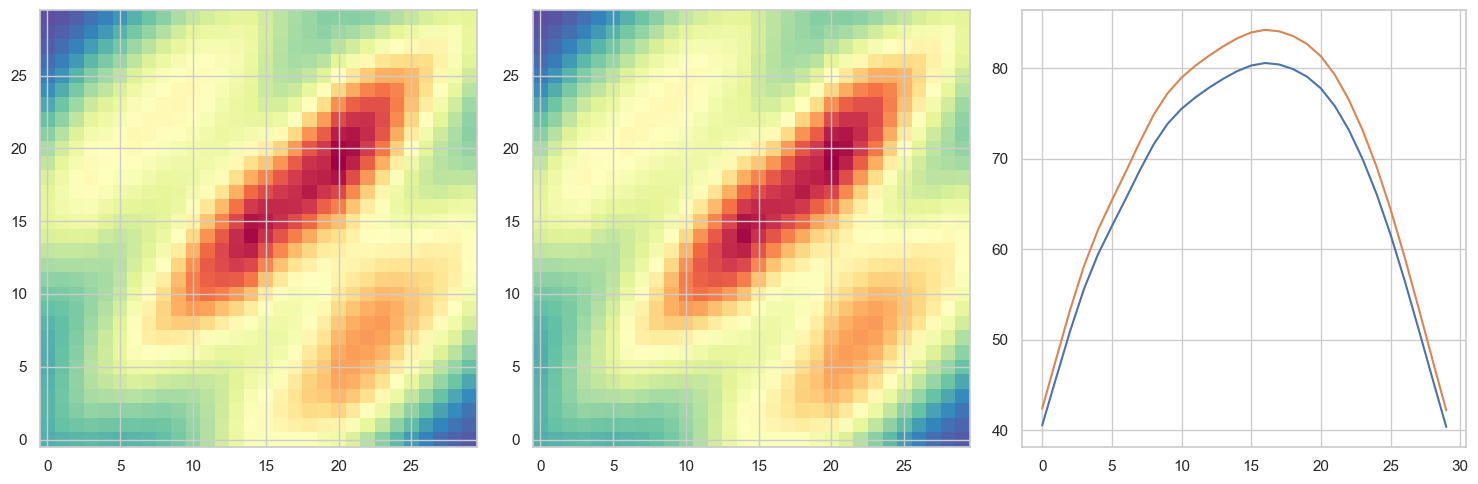

In [10]:
# Plot posterior contact intensity
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

A = 30
po_cint_0 = po_cint[0:A**2]
po_cint_1 = po_cint[A**2:]
y0 = po_cint_0['q50'].values.reshape(A, A, order='F')
y1 = po_cint_1['q50'].values.reshape(A, A, order='F')
y0_margin = y0.sum(axis=1)
y1_margin = y1.sum(axis=1)

ax[0].imshow(y0, cmap=cm.Spectral.reversed(), origin='lower')
ax[1].imshow(y1, cmap=cm.Spectral.reversed(), origin='lower')
ax[2].plot(y0_margin)
ax[2].plot(y1_margin)

plt.tight_layout()
plt.show()

In [20]:
print(idata.posterior['baseline'].shape)
print(idata.posterior['log_delta_X_a'].shape)

(4, 500)
(4, 500, 2, 900)


In [23]:
po_sum = az.summary(idata, var_names=['log_delta_X_a'])

array([-0.015, -0.015, -0.015, ...,  0.029,  0.029,  0.029])

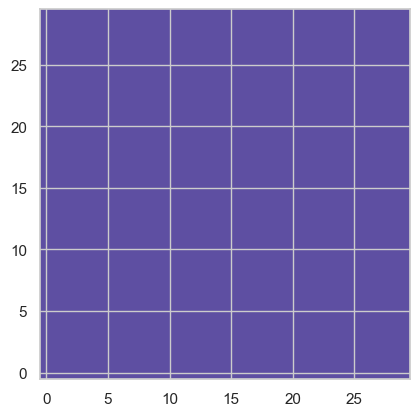

In [30]:
y = po_sum['mean'].values.reshape(2, 30, 30)[0,:,:]
plt.imshow(np.exp(y), cmap=cm.Spectral.reversed(), origin='lower')

In [34]:
# Extract posterior contact rate
po_rate_0 = az.summary(idata, var_names='log_gam_0', stat_funcs=func_dict, extend=False)
po_rate_1 = az.summary(idata, var_names='log_gam_1', stat_funcs=func_dict, extend=False)
po_rate_0 = po_rate_0.map(np.exp)
po_rate_1 = po_rate_1.map(np.exp)

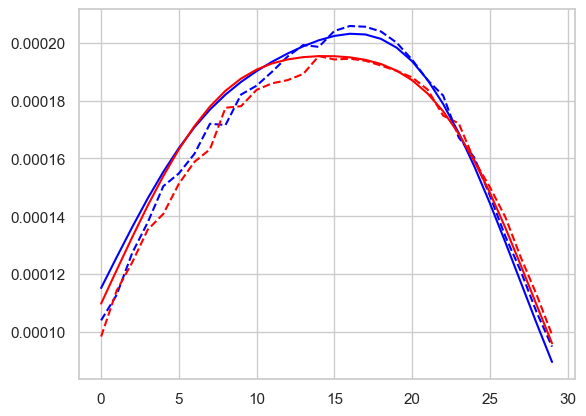

In [35]:
y0 = po_rate_0['q50'].values.reshape(A, A, order='F').sum(axis=1)
y1 = po_rate_1['q50'].values.reshape(A, A, order='F').sum(axis=1)
y_true_0 = df['true_rate'].values[0:A**2].reshape(A, A, order='F').sum(axis=1)
y_true_1 = df['true_rate'].values[A**2:].reshape(A, A, order='F').sum(axis=1)

fig, ax = plt.subplots()
ax.plot(y0, linestyle='--', color='blue')
ax.plot(y1, linestyle='--', color='red')
ax.plot(y_true_0, color='blue')
ax.plot(y_true_1, color='red')

plt.show()

In [11]:
np.concatenate((data['pop_ratio']['X_a'], data['pop_ratio']['X_a']), axis=0).shape

(60, 2)